# Genetic miner
 # Plan: Implement the Genetic Miner on the BPIC-17 log

## Context

The project already evaluates three pm4py discovery algorithms (Inductive, Alpha, Heuristics) on the BPIC-17 event log in `notebooks/process_model_creation_validation.ipynb`. The course brief asks for "at least two" discovery algorithms — adding the **Genetic Miner** strengthens the comparison and is a natural fourth method.

`pm4py.discover_petri_net_genetic` defaults (`population_size=500`, `generations=100`) imply ~50,000 token-replay evaluations on a 27,816-event log — many hours of runtime. We need a configuration that produces a meaningful model in ~30–60 minutes while remaining comparable to the other miners. We will keep the same evaluation pattern (fitness / precision / generalization + custom simplicity metrics) so the new model slots straight into the comparison table.

## Approach

Create a **new notebook** `notebooks/genetic_miner.ipynb` that mirrors the structure of `process_model_creation_validation.ipynb`. It runs the genetic miner on a **variant-filtered** version of the log (top variants covering ~80% of cases) for tractable runtime, then evaluates the resulting Petri net on the **full filtered log** so the metrics are directly comparable to the other miners.

## Notebook structure

1. **Imports** — match the existing notebook: `pm4py`, `pandas`, `os`, `networkx`. Include `import time` to log elapsed runtime.

2. **Load event log** — same as `process_model_creation_validation.ipynb`:
   ```python
   df = pd.read_csv("../data/renamed_log.csv", low_memory=False)
   df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], format='mixed', utc=True)
   event_log = pm4py.format_dataframe(df, case_id='case:concept:name',
                                      activity_key='concept:name',
                                      timestamp_key='time:timestamp')
   ```

3. **Build a reduced log for discovery only** — use pm4py's variant filter to keep variants that together cover ~80% of cases:
   ```python
   discovery_log = pm4py.filter_variants_by_coverage_percentage(event_log, 0.0001)
   # equivalent: pm4py.filter_variants_top_k for a hard cap (e.g. top 50 variants)
   ```
   Print before/after case and variant counts so the reduction is documented in the report.

4. **Re-import the simplicity helpers** — copy `calculate_node_size`, `calculate_arc_size`, `calculate_cyclicity` from `process_model_creation_validation.ipynb` (cells `2b0e4175` and `b76cfd86`) so the notebook stands alone. (Alternative: extract them to `utils/simplicity.py` — out of scope here unless the user asks.)

5. **Run the genetic miner** with a balanced configuration:
   ```python
   t0 = time.time()
   genetic_net, genetic_im, genetic_fm = pm4py.discover_petri_net_genetic(
       discovery_log,
       population_size=50,
       generations=20,
       elitism_rate=0.05,
       crossover_rate=1.0,
       mutation_rate=0.05,
       elitism_min_sample=5,
   )
   print(f"Runtime: {time.time()-t0:.1f}s")
   pm4py.view_petri_net(genetic_net, genetic_im, genetic_fm)
   ```
   Rationale for non-defaults:
   - `population_size=50` and `generations=20` → ~1,000 evaluations vs. 50,000 (50× speedup).
   - `mutation_rate=0.05` (vs. 0.01) — a smaller population needs more exploration to avoid premature convergence.
   - `elitism_rate=0.05` — keeps a handful of best individuals each generation rather than ~0.5 (50 × 0.01).

6. **Evaluate on the full filtered `event_log`** (not the reduced one) so metrics are comparable to the other miners — same calls as cell `c9894a2a`:
   ```python
   genetic_generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(
       event_log, genetic_net, genetic_im, genetic_fm)
   genetic_precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(
       event_log, genetic_net, genetic_im, genetic_fm)
   genetic_fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(
       event_log, genetic_net, genetic_im, genetic_fm)
   ```

7. **Custom simplicity metrics** — call `calculate_node_size`, `calculate_arc_size`, `calculate_cyclicity` on `genetic_net`.





- import libraries:

In [1]:
import pm4py # process mining library
import pandas as pd # data manipulation library
import os # operating system library for file handling
import matplotlib.pyplot as plt # plotting library for visualizations
import numpy as np # numerical computing library for data analysis
import networkx as nx # library for graph analysis and visualization
import time # library for measuring execution time of code blocks

- load only completed and relabled events 

In [2]:
df = pd.read_csv("../data/renamed_log.csv", low_memory=False)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'], format='mixed', utc=True)
event_log = pm4py.format_dataframe(df, case_id='case:concept:name', activity_key='concept:name', timestamp_key='time:timestamp')


- reduce data log for discovery:

In [3]:
discovery_log = pm4py.filter_variants_by_coverage_percentage(event_log, 0.0001)
# equivalent: pm4py.filter_variants_top_k for a hard cap (e.g. top 50 variants)

- a first simple simplicity metrics is the size (arcs and nodes) that is implemented in the following way:

In [4]:
def calculate_node_size(net):
    """
    Calculates the total number of nodes in a pm4py Petri net.
    Nodes = Places + Transitions
    """
    num_places = len(net.places)
    num_transitions = len(net.transitions)
    
    return num_places + num_transitions

def calculate_arc_size(net):
    """
    Calculates the total number of arcs (edges) in a pm4py Petri net.
    """
    return len(net.arcs)

- another metric that makes sense in general is the cyclicity of the net
- implementation:

In [5]:
def calculate_cyclicity(net):
    """
    Calculates the cyclicity of a pm4py Petri net.
    Cyclicity = (number of nodes within cycles) / (total number of nodes)
    
    :param net: pm4py Petri net object
    :return: Float representing the cyclicity metric (between 0.0 and 1.0)
    """
    # 1. Calculate total number of nodes (Places + Transitions)
    total_nodes = len(net.places) + len(net.transitions)
    
    if total_nodes == 0:
        return 0.0
        
    # 2. Build a NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Add all places and transitions as nodes
    for place in net.places:
        G.add_node(place)
    for transition in net.transitions:
        G.add_node(transition)
        
    # Add all arcs as directed edges
    for arc in net.arcs:
        G.add_edge(arc.source, arc.target)
        
    # 3. Identify nodes in cycles
    # A node is in a cycle if it is part of a Strongly Connected Component (SCC)
    # with more than 1 node, or if it is a single node with a self-loop.
    nodes_in_cycles = set()
    
    for scc in nx.strongly_connected_components(G):
        if len(scc) > 1:
            # All nodes in an SCC of size > 1 are part of a cycle
            nodes_in_cycles.update(scc)
        elif len(scc) == 1:
            # Check for self-loops for single-node components
            node = list(scc)[0]
            if G.has_edge(node, node):
                nodes_in_cycles.add(node)
                
    # 4. Calculate the cyclicity ratio
    cyclicity = len(nodes_in_cycles) / total_nodes
    
    return cyclicity

### process discovery 

- genetic miner:

└─Tournament 0:   0%|          | 0/50 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/688 [00:00<?, ?it/s]

└─Tournament 0:   2%|▏         | 1/50 [00:01<01:28,  1.82s/it]

replaying log with TBR, completed traces ::   0%|          | 0/688 [00:00<?, ?it/s]

└─Tournament 0:   4%|▍         | 2/50 [00:02<01:02,  1.30s/it]

...

replaying log with TBR, completed traces ::   0%|          | 0/688 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/688 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/688 [00:00<?, ?it/s]

Genetic generations: 100%|██████████| 20/20 [29:44<00:00, 89.23s/it]


Runtime: 1871.6s


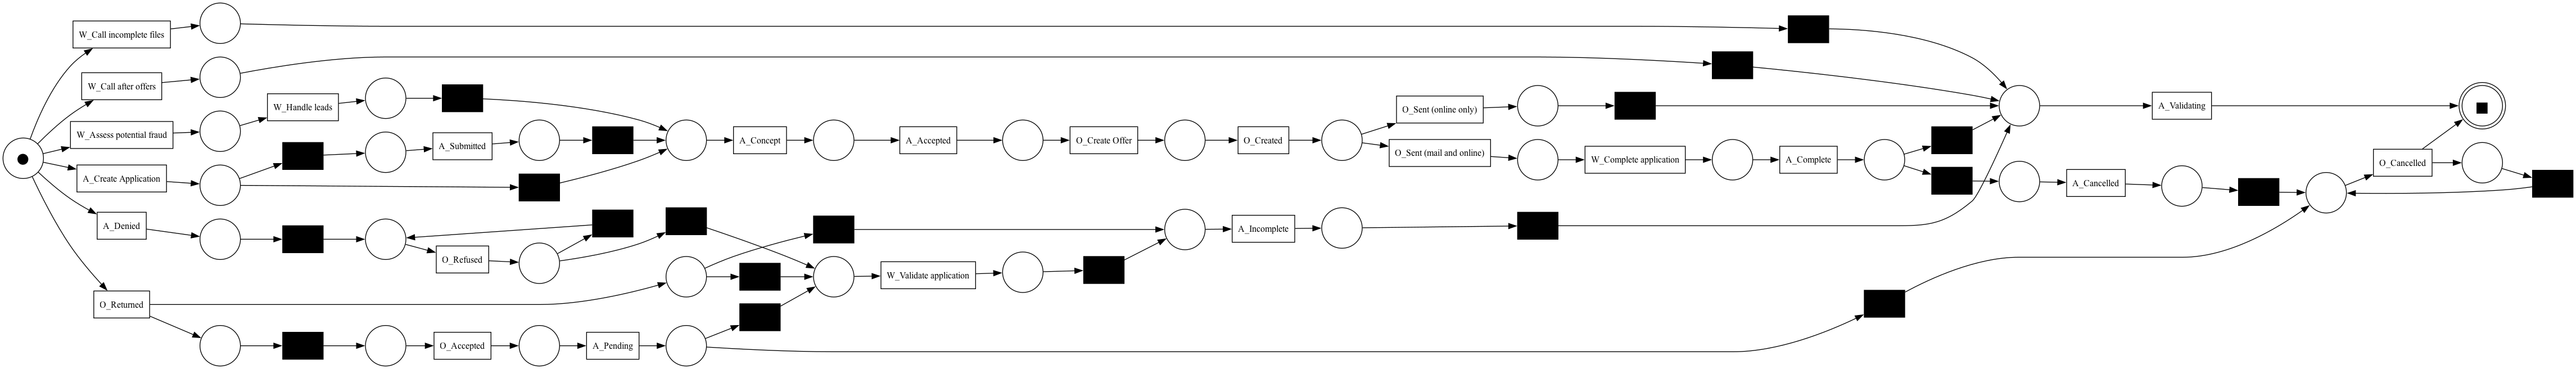

In [10]:
t0 = time.time()
genetic_net, genetic_im, genetic_fm = pm4py.discover_petri_net_genetic(
    discovery_log,
    population_size=50,
    generations=20,
    elitism_rate=0.05,
    crossover_rate=1.0,
    mutation_rate=0.05,
    elitism_min_sample=5,
)
print(f"Runtime: {time.time()-t0:.1f}s")
pm4py.view_petri_net(genetic_net, genetic_im, genetic_fm)

- calculate conformance metrics:

In [11]:
genetic_generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(event_log, genetic_net, genetic_im, genetic_fm)
genetic_precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(event_log, genetic_net, genetic_im, genetic_fm)
genetic_fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(event_log, genetic_net, genetic_im, genetic_fm)
print(f"Generalization: {genetic_generalization:.4f}")
print(f"Precision: {genetic_precision:.4f}")
print(f"Fitness: {genetic_fitness}")

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Generalization: 0.8993
Precision: 0.6409
Fitness: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.8779782766509443, 'log_fitness': 0.8691543567308523, 'percentage_of_fitting_traces': 0.0}


- calculate simplicity

In [12]:
genetic_node_size = calculate_node_size(genetic_net)
genetic_arc_size = calculate_arc_size(genetic_net)
genetic_cyclicity = calculate_cyclicity(genetic_net)
print(f"Node Size: {genetic_node_size}")
print(f"Arc Size: {genetic_arc_size}")
print(f"Cyclicity: {genetic_cyclicity:.4f}")

Node Size: 80
Arc Size: 92
Cyclicity: 0.1000


- store the petri net in the correct directory

In [13]:
# Define the target directory and file name for saving the Petri net visualization
target_dir = "../petrinets/genetic"
file_name = "petri_net_genetic.pdf"
full_path = os.path.join(target_dir, file_name)

# create target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Save the Petri net visualization to a file
pm4py.save_vis_petri_net(genetic_net, genetic_im, genetic_fm, full_path)

''

- save as loadable model

In [15]:

target_dir = "../petrinets/genetic"
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

file_path = os.path.join(target_dir, "genetic_model.pnml")

# Save the Petri net model
pm4py.write_pnml(genetic_net, genetic_im, genetic_fm, file_path)

### Overview relevant metrics

In [17]:

# Initialize the dictionary with lists for both conformance and simplicity metrics
metrics_dict = {
    'Model': [],
    'Fitness (Log)': [],
    'Fitness (Avg Trace)': [],
    'Fitness (% Fit Traces)': [],
    'Precision': [],
    'Generalization': [],
    'Node Size': [],
    'Arc Size': [],
    'Cyclicity': []
}

# Add base models
metrics_dict['Model'].append('Genetic Miner ')

# Add Conformance Metrics 
# (Make sure these variables have been generated in the previous cells)
metrics_dict['Fitness (Log)'].append(genetic_fitness['log_fitness'])
metrics_dict['Fitness (Avg Trace)'].append(genetic_fitness['average_trace_fitness'])
metrics_dict['Fitness (% Fit Traces)'].append(genetic_fitness['perc_fit_traces'])
metrics_dict['Precision'].append(genetic_precision)
metrics_dict['Generalization'].append(genetic_generalization)

# Add Simplicity Metrics
metrics_dict['Node Size'].append(genetic_node_size)
metrics_dict['Arc Size'].append(genetic_arc_size)
metrics_dict['Cyclicity'].append(genetic_cyclicity)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_dict)

# Print the formatted table
print("=" * 135)
print("CONFORMANCE & SIMPLICITY METRICS - GENETIC MINER")
print("=" * 135)
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 135)

CONFORMANCE & SIMPLICITY METRICS - GENETIC MINER
         Model  Fitness (Log)  Fitness (Avg Trace)  Fitness (% Fit Traces)  Precision  Generalization  Node Size  Arc Size  Cyclicity
Genetic Miner          0.8692               0.8780                  0.0000     0.6409          0.8993         80        92     0.1000
